In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression ,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv('/content/test_energy_data.csv')
df

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59
...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81
96,Residential,37943,50,23,21.73,Weekend,4248.49
97,Commercial,1558,27,29,16.86,Weekend,2843.60
98,Industrial,2145,56,12,11.77,Weekend,3348.39


In [ ]:
print(df.info())
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB
None
                     count        mean           std      min         25%  \
Square Footage       100.0  25881.9200  13711.075264  1161.00  14161.0000   
Number of Occupants  100.0     47.2300     29.905526     2.00     21.0000   
Appliances Used      100.0     26.9700     14.237846     1.00     16.7500   
Average Temperature  100.0     22.0433      6.957951    10.40     15.682

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

<Axes: xlabel='Building Type', ylabel='count'>

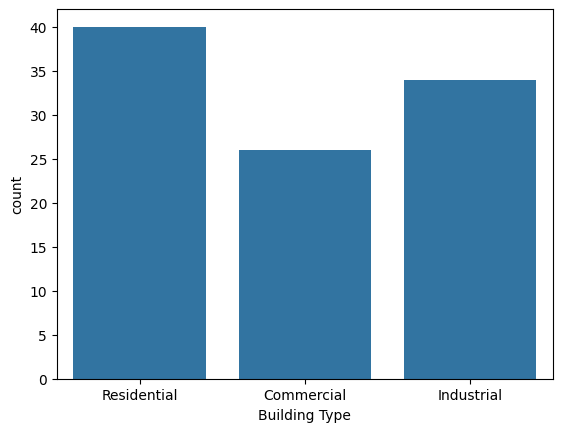

In [ ]:
sns.countplot(x='Building Type', data=df)

<Axes: xlabel='Day of Week', ylabel='count'>

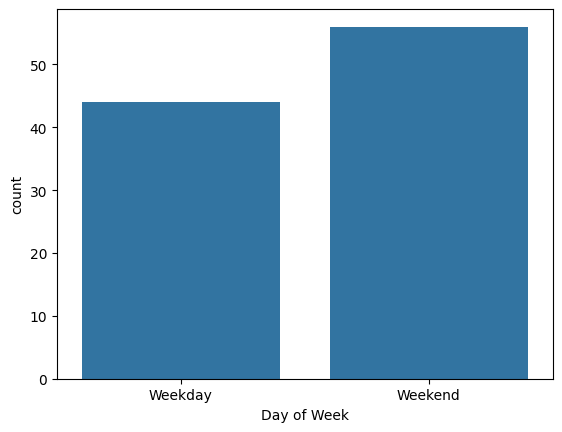

In [ ]:
sns.countplot(x='Day of Week', data=df)

In [ ]:
x = df.iloc[:,:6]
y = df.iloc[:,6]
x,y

(   Building Type  Square Footage  Number of Occupants  Appliances Used  \
 0    Residential           24563                   15                4   
 1     Commercial           27583                   56               23   
 2     Commercial           45313                    4               44   
 3    Residential           41625                   84               17   
 4    Residential           36720                   58               47   
 ..           ...             ...                  ...              ...   
 95    Commercial            1161                   81               11   
 96   Residential           37943                   50               23   
 97    Commercial            1558                   27               29   
 98    Industrial            2145                   56               12   
 99   Residential           42414                   72               24   
 
     Average Temperature Day of Week  
 0                 28.52     Weekday  
 1                 2

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [ ]:
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns
num_features, cat_features

(Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
        'Average Temperature'],
       dtype='object'),
 Index(['Building Type', 'Day of Week'], dtype='object'))

In [ ]:
processing = ColumnTransformer([
    ('num_processing', MinMaxScaler(), num_features),
    ('cat_processing', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Support Vector Machine': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

In [ ]:
result = {}

for name, regressor in models.items():
  pipe = Pipeline([
      ('processing', processing),
      ('model', regressor)
  ])

  pipe.fit(x_train, y_train)
  y_pred = pipe.predict(x_test)
  score = r2_score(y_test, y_pred)
  result[name] = score

  print(f'{name}: {score}')

best_model = max(result, key=result.get)
print(f'\nBest Model: {best_model} with Score:{result[best_model]}')


Linear Regression: 0.9999999998126238
Ridge Regression: 0.9854822298593348
Random Forest: 0.8369446833491583
Decision Tree: 0.729552258449123
Support Vector Machine: -0.005633119526284425
K-Nearest Neighbors: 0.6985197044597109

Best Model: Linear Regression with Score:0.9999999998126238


In [ ]:

new_data = pd.DataFrame({
    'Building Type': ['Residential'],
    'Day of Week': ['Monday'],
    'Average Temperature': [25.0],
    'Square Footage':[27583],
    'Number of Occupants':[56],
    'Appliances Used':[23]

})

pipe.predict(new_data)



array([3829.072])